# HW6 Julia Scripts

In [191]:
include(joinpath(@__DIR__, "..", "readclassjson.jl"))
using JSON
using LinearAlgebra
using Plots
using ForwardDiff
using Pkg
Pkg.add("LaTeXStrings")
using LaTeXStrings
using Statistics
Pkg.add("Measures")
using Measures

   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`
   Resolving package versions...
     Project No packages added to or removed from `~/.julia/environments/v1.12/Project.toml`
    Manifest No packages added to or removed from `~/.julia/environments/v1.12/Manifest.toml`


## Q1 (6.3200) Fitting a Piecewise Linear Function to Data

In [204]:
tempdata_data = readclassjson("tempdata.json")
x_train = tempdata_data["x_train"]
y_train = tempdata_data["y_train"]
x_test = tempdata_data["x_test"]
y_test = tempdata_data["y_test"]

function fit(x, m, y)
    n = length(x)
    F = ones(n, m+1)
    # construct F
    for i in 1:n
        for j in 1:m
            if x[i] < (12/m)*(j-1)
                F[i,j+1] = 0
            elseif x[i] >= (12/m)*(j - 1) && x[i] <= (12/m)*j
                F[i,j+1] = (m*x[i]/12) - (j - 1)
            end
        end
    end
    alpha = pinv(F) * y
    g = F * alpha
    return alpha, g, F
end



fit (generic function with 1 method)

In [207]:
m = [3, 6, 12, 24]
a3_train, g3_train, F3_train = fit(x_train, m[1], y_train)
a6_train, g6_train, F6_train = fit(x_train, m[2], y_train)
a12_train, g12_train, F12_train = fit(x_train, m[3], y_train)
a24_train, g24_train, F24_train = fit(x_train, m[4], y_train)

([44.75478638010979, 2.9063627137376344, -3.18796035395891, 16.740397996963853, -0.21490654500706133, 2.2952859190248396, 12.34394305334979, -3.7965458155194223, 5.289691941544843, 8.240875683968886  …  -7.29529582538397, -6.106345541196259, -6.778935497142095, -7.90928593406937, -4.72427430573142, -3.3340638029824445, -13.559182879219632, -1.2854990184008246, 2.1474975318086016, -6.183376812408936], [44.75478638010979, 47.66114909384743, 44.47318873988852, 61.21358673685238, 60.99868019184532, 63.29396611087016, 75.63790916421995, 71.84136334870053, 77.13105529024537, 85.37193097421425  …  90.74255633755595, 84.63621079635969, 77.85727529921759, 69.94798936514822, 65.2237150594168, 61.88965125643436, 48.33046837721473, 47.0449693588139, 49.192466890622505, 43.00909007821357], [1.0 0.0 … 0.0 0.0; 1.0 1.0 … 0.0 0.0; … ; 1.0 1.0 … 1.0 0.0; 1.0 1.0 … 1.0 1.0])

┌ Warning: Skipped marker arg circle.
└ @ Plots ~/.julia/packages/Plots/8ZnR3/src/args.jl:1155


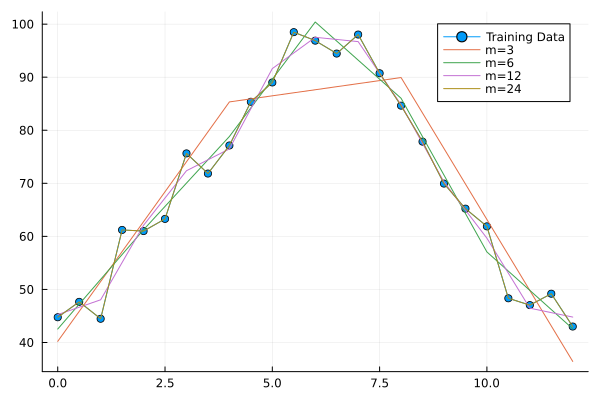

In [209]:
plot_c = plot(x_train, y_train, marker="circle", label="Training Data")
plot!(plot_c, x_train, g3_train, label="m=3")
plot!(plot_c, x_train, g6_train, label="m=6")
plot!(plot_c, x_train, g12_train, label="m=12")
plot!(plot_c, x_train, g24_train, label="m=24")

### Minimal Squared 2-norm error

┌ Warning: Skipped marker arg circle.
└ @ Plots ~/.julia/packages/Plots/8ZnR3/src/args.jl:1155


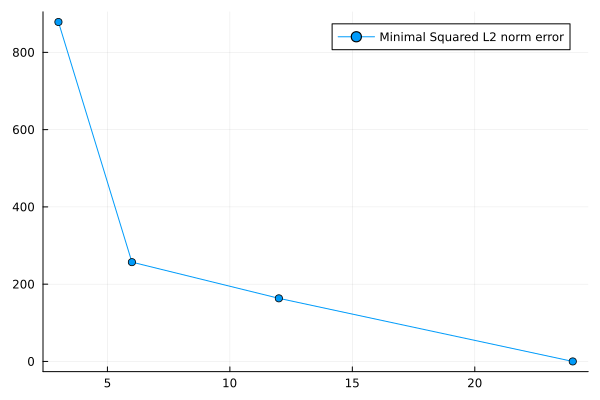

In [210]:
ms3_train = norm(y_train - g3_train)^2
ms6_train = norm(y_train - g6_train)^2
ms12_train = norm(y_train - g12_train)^2
ms24_train = norm(y_train - g24_train)^2

ms_train = [ms3_train, ms6_train, ms12_train, ms24_train]

plot_d = plot(m, ms_train, marker="circle", label="Minimal Squared L2 norm error")

### Part e Test error

┌ Warning: Skipped marker arg circle.
└ @ Plots ~/.julia/packages/Plots/8ZnR3/src/args.jl:1155


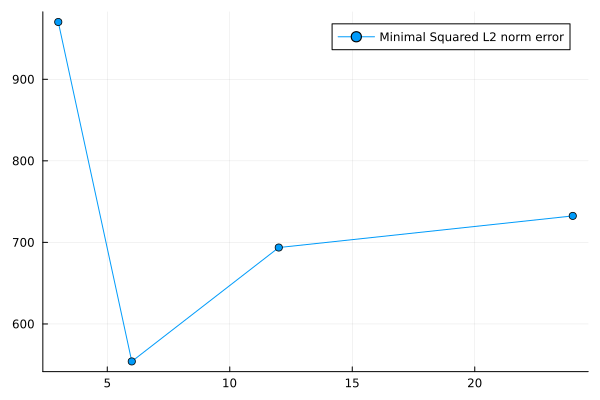

In [ ]:
_, _, F3_test = fit(x_test, m[1], y_test)
_, _, F6_test = fit(x_test, m[2], y_test)
_, _, F12_test = fit(x_test, m[3], y_test)
_, _, F24_test = fit(x_test, m[4], y_test)

g3_test = F3_test * a3_train
g6_test = F6_test * a6_train
g12_test = F12_test * a12_train
g24_test = F24_test * a24_train

ms3_test = norm(y_test - g3_test)^2
ms6_test = norm(y_test - g6_test)^2
ms12_test = norm(y_test - g12_test)^2
ms24_test = norm(y_test - g24_test)^2

ms_test = [ms3_test, ms6_test, ms12_test, ms24_test]
plot_e = plot(m, ms_test, marker="circle", 
              label="Minimal Squared L2 norm error")

## Q2 (7.1040)

#### Plot t vs y

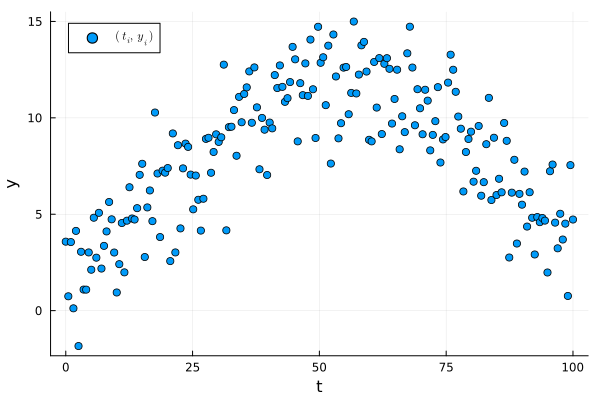

In [ ]:
gauss_fit_data = readclassjson("gauss_fit_data.json")

t = gauss_fit_data["t"]
y = gauss_fit_data["y"]

p2 = plot(t, y, seriestype=:scatter, label=L"(\,t_i,\, y_i\,)")
xlabel!(p2, "t")
ylabel!(p2, "y")

In [ ]:
N = gauss_fit_data["N"]

f(t, p) = p[1] .* exp.(-(t .- p[2]).^2 / p[3]^2) # p = [a mu, sigma]'
r(p) = f(t, p) - y

# Gauss-Newton:
function gauss_newton_fit_plot(pk_init)
    MAX_ITERS = 20
    eps = 10e-3
    pk = copy(pk_init) # copy to not modify og
    E_0 = ((1/N) * norm(r(pk))^2)^(0.5)
    Es = Float64[]
    ks = Int[]

    for k in 0:MAX_ITERS # avoid inf loop
        J = ForwardDiff.jacobian(r, pk)
        delta_p = -(J' * J) \ (J' * r(pk))
        pk += delta_p    

        E = ((1/N) * norm(r(pk))^2)^(0.5)
        push!(Es, E)
        push!(ks, k)

        if norm(delta_p) < eps
            break
        end
    end
    p_gauss = plot(t, y, seriestype=:scatter, label=L"(\,t_i,\, y_i\,)")
    plot!(p_gauss, t, f(t, pk_init), label="Initial guess p₀", linestyle=:dash)
    plot!(p_gauss, t, f(t, pk),
        label = "Final Gaussian function",
        title = "Gaussian function fit with p₀ = [a=$(pk_init[1]) , μ=$(pk_init[2]), σ=$(pk_init[3])]",
        titlefont = 10)
        

    p_E_vs_k = plot(ks, Es, title="RMS Error vs Iteration",
                   xlabel="Iteration (k)", ylabel="RMS Error E",
                   label="E vs k", marker="circle", legend=:topright)
    display(p_gauss)
    display(p_E_vs_k)
end

gauss_newton_fit_plot (generic function with 1 method)

┌ Warning: Skipped marker arg circle.
└ @ Plots ~/.julia/packages/Plots/8ZnR3/src/args.jl:1155


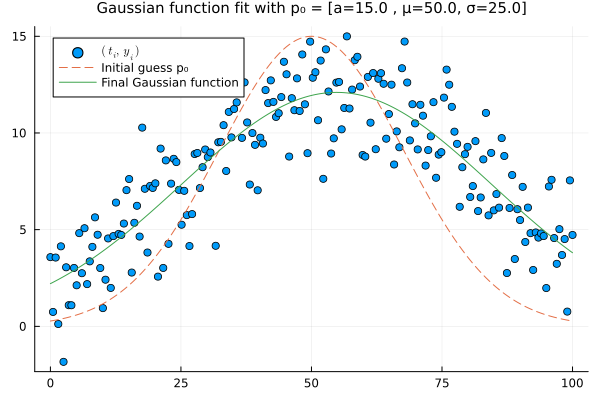

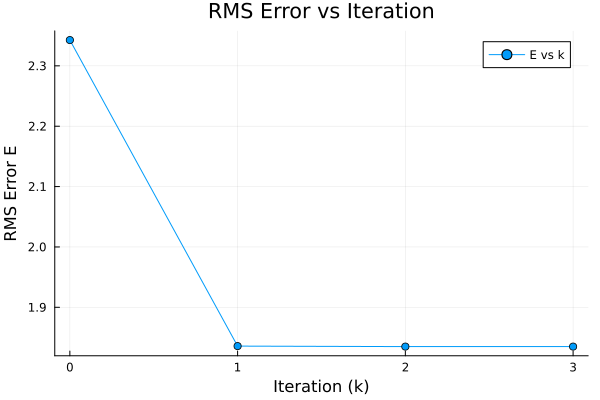

┌ Warning: Skipped marker arg circle.
└ @ Plots ~/.julia/packages/Plots/8ZnR3/src/args.jl:1155


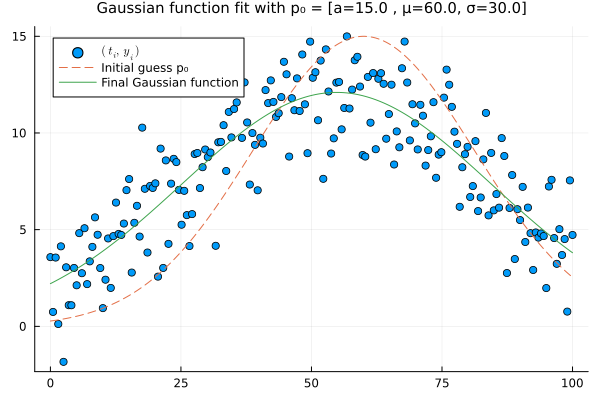

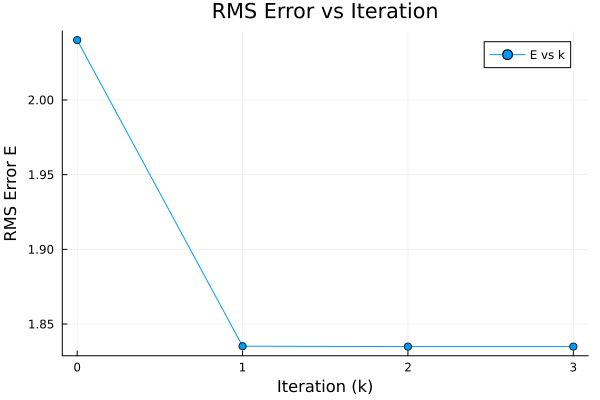

┌ Warning: Skipped marker arg circle.
└ @ Plots ~/.julia/packages/Plots/8ZnR3/src/args.jl:1155


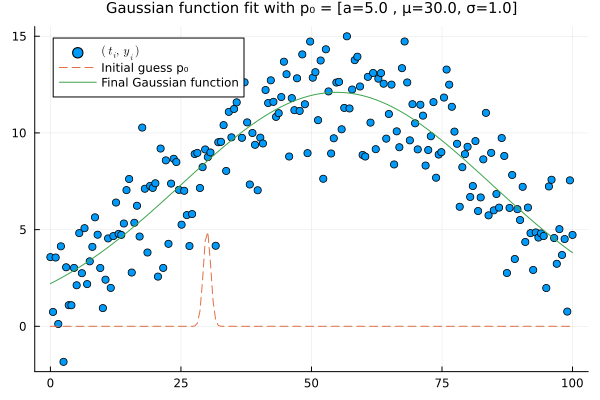

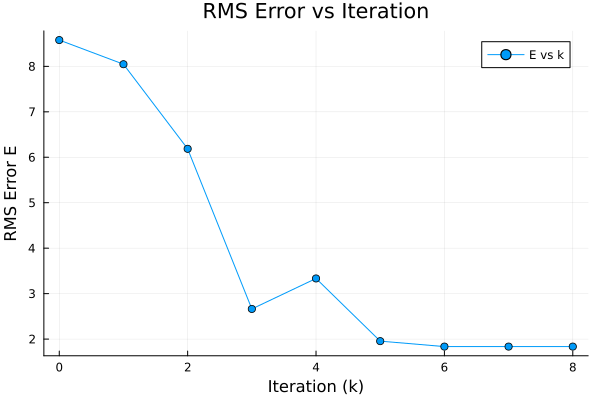

In [ ]:
pk1 = [15.0, 50.0, 25.0] # good guess
pk2 = [15.0, 60, 30] # alt guess
pk3 = [5.0, 30, 1] # crazy guess

gauss_newton_fit_plot(pk1)
gauss_newton_fit_plot(pk2)
gauss_newton_fit_plot(pk3)

## Q3 (8.1460) Filling in Missing Data

### Populates z vector with known y_i values

In [ ]:
missing = readclassjson("missing.json")
K = missing["known"] # list of known points K
y = missing["y"] # list of values y at K
n = 100

# Create z_vec with z_i = y_i for known i 
z = zeros(Float64, n)
for (idx, i) in enumerate(K)
    z[i] = y[idx] # skips through nonexistent y_i for z
end

### Part c) Find optimal z under minimizing z_der = z_i+1 - z_i

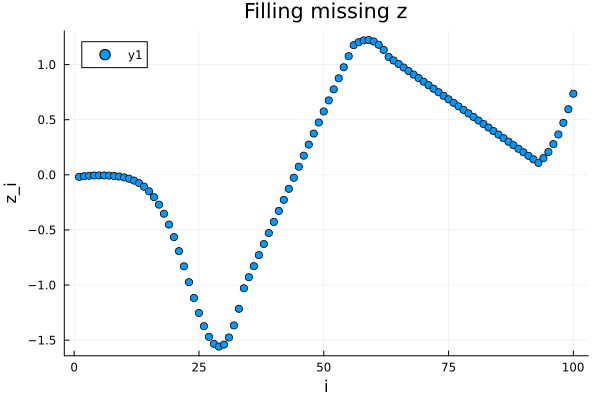

In [ ]:
# Find empty intervals
intervals = []
in_gap = false
a = 0
z_a = 0.0

for j in 1:n
    if z[j] == 0 && !in_gap # start of zero interval
        in_gap = true
        a = j - 1
        if j > 0
            z_a = z[j-1]
        else
            z_a = 0
        end
    elseif z[j] != 0 && in_gap # end of zero interval
        z_b = z[j]
        b = j
        push!(intervals, (a, z_a, b, z_b))
        in_gap = false
    end
end

# If last elements are missing
if in_gap
    push!(intervals, (a, n))
end

# Linearly interpolate empty z values 
for (a, z_a, b, z_b) in intervals
    for j in (a+1):(b-1)
        z[j] = z[a] + (z[b] - z[a]) * ((j - a)/(b - a))
    end
end

p_3c = scatter(1:n, z, title="Filling missing z", 
               xlabel="i", ylabel="z_i")
display(p_3c)

### Part e) Multiobjective minimization of z

#### Define and populate G and H matrices

In [ ]:
G = zeros((n - 1, n))
H = zeros((n - 2, n))

# Populate G
for i in 1:n-1
    G[i, i] = -1
    G[i, i + 1] = 1
end

# Populate H
for i in 1:n-2
    H[i, i] = 1
    H[i, i + 2] = 1
    H[i, i + 1] = -2
end

C = zeros(length(K), 100)
for (idx, i) in enumerate(K)
    C[idx, i] = 1
end

### Plot J1 vs J2

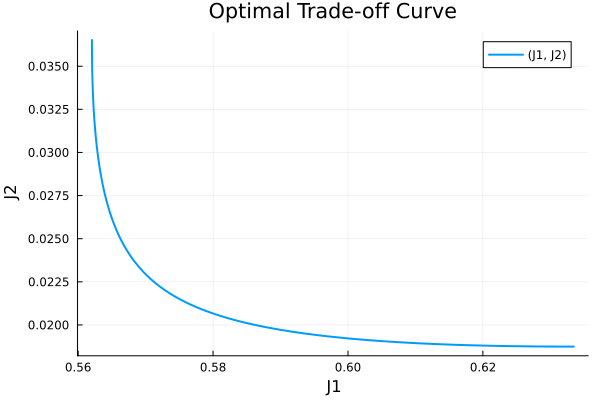

In [ ]:
KKT = zeros(n+length(K), n+length(K))

J1 = Float64[]
J2 = Float64[]

# Sweeping mu parameters
mu_sweep = logrange(10^-4, 10^4, 1000)
for mu in mu_sweep
    KKT = [G'*G+mu*H'*H C'; C zeros(length(K), length(K))]
    y_tilda = [zeros(n); y]
    z_tilda = KKT \ y_tilda
    z_new = z_tilda[1:n, 1]
    push!(J1, norm(G*z_new)^2)
    push!(J2, norm(H*z_new)^2)
end

plot_f = plot(J1, J2, title="Optimal Trade-off Curve",
label="(J1, J2)",
xlabel = "J1",
ylabel = "J2",
linewidth=2)

display(plot_f)

### Find Optimal z for µ = 5, 20, 100

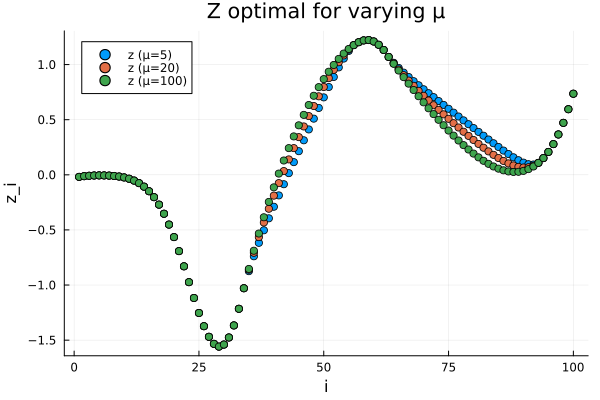

In [ ]:
mu_vary = [5 20 100]
z_opt = []

for mu in mu_vary
    KKT = [G'*G+mu*H'*H C'; C zeros(length(K), length(K))]
    y_tilda = [zeros(n); y]
    z_tilda = KKT \ y_tilda
    z_new = z_tilda[1:n, 1]
    push!(z_opt, z_new)
end

plot_g = scatter(1:n, z_opt[1], label="z (µ=5)", 
                 title="Z optimal for varying µ", 
                 xlabel="i", ylabel="z_i")
scatter!(plot_g, 1:n, z_opt[2], label="z (µ=20)")
scatter!(plot_g, 1:n, z_opt[3], label="z (µ=100)")
display(plot_g)

## Q4 (11.1830) Estimating a matrix with known eigenvectors

In [ ]:
A_meas = [2.0 1.2 -1.0
          0.4 2.0 -0.5
         -0.5 0.9 1.0]

v1 = [0.7, 0, 0.7]
v2 = [0.3, 0.6, 0.7]
v3 = [0.6, 0.6, 0.3]

3-element Vector{Float64}:
 0.6
 0.6
 0.3

### Finding A_hat

In [ ]:
V = hcat(v1, v2, v3)
Vinv = inv(V)
n = 3

# Construct B
B = zeros(n^2, n)
for i in 1:n
    v_i = V[1:n, i]
    w_i = Vinv[i,1:n]
    vwT = v_i * w_i'
    B[:, i] = vwT[:]
end
lambda_star = (B'*B) \ (B' * A_meas[:])

# Construct A_hat
a_hat = B * lambda_star
A_hat = reshape(a_hat, n, n)
display(A_hat)

3×3 Matrix{Float64}:
  1.74724   1.1502    -0.96321
  0.527733  2.15196   -0.527733
 -0.316769  0.974285   1.1008

### Verify A_hat eigenvectors

In [ ]:

v1_hat = A_hat * v1 / lambda_star[1]
v2_hat = A_hat * v2 / lambda_star[2]
v3_hat = A_hat * v3 / lambda_star[3]

println("A_hat eigenvector (should match $v1) = $v1_hat")
println("A_hat eigenvector (should match $v2) = $v2_hat")
println("A_hat eigenvector (should match $v3) = $v3_hat")

A_hat eigenvector (should match [0.7, 0.0, 0.7]) = [0.7000000000000001, 1.57313535178858e-17, 0.7000000000000001]
A_hat eigenvector (should match [0.3, 0.6, 0.7]) = [0.3, 0.6, 0.7000000000000002]
A_hat eigenvector (should match [0.6, 0.6, 0.3]) = [0.6, 0.6000000000000001, 0.3000000000000001]


### Value of J

In [ ]:
J = (1/n^2) * norm(A_meas[:] - A_hat[:])^2
println("J: $J")

J: 0.01746133343860545
